# Naive Quaternion Fitting using B-Spline in Euclidean Space

Simple approximation of quaternion sequences by LSPIA using B-Spline on euclidean basis and re-normalization.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import make_lsq_spline

from src.utils import prepare_clip, pack_frame_to_matrix

from src.kinematics import forward_kinematics
from src.viz.animate import AnimatedSkeletonsPlotter, AnimatedRotationsPlotter

---
## Load Test Clip

In [83]:
CLIP_IDX = 72
ANIM_STRIDE = 4

In [84]:
data = np.load(f"data/npz/clip_{CLIP_IDX}.npz", allow_pickle=True)
clip = data["clip"].item()
clip, clip_name, clip_quats = prepare_clip(clip)

In [85]:
pl = AnimatedSkeletonsPlotter(title=clip_name, stride=ANIM_STRIDE).apply_defualt_layout()
pl.add_skeleton_frames(forward_kinematics(clip_quats))
pl.show()

---
## Approximate (Compress) the Clip

In [86]:
JOINT_NAMES      = clip_quats.keys()
NUM_JOINTS       = len(JOINT_NAMES)
NUM_FRAMES       = clip_quats["rootx"].shape[0]

SPLINE_DEGREE    = 2
NUM_SPLINE_CPS   = int(NUM_FRAMES / 10)
NUM_SPLINE_KNOTS = NUM_SPLINE_CPS + SPLINE_DEGREE + 1

print(f"-> {NUM_FRAMES:<4} frames")
print(f"-> {NUM_SPLINE_CPS:<4} control points")
print(f"-> {NUM_SPLINE_KNOTS:<4} knots")

-> 346  frames
-> 34   control points
-> 37   knots


In [87]:
def generate_open_knots(degree, num_cps):
    if num_cps < degree + 1:
        raise ValueError(f"num_cps have to be >= degree + 1, got degree={degree} and num_cps={num_cps}")
    
    num_interior = num_cps - degree - 1

    head = np.repeat(0, degree + 1)
    tail = np.repeat(1, degree + 1)
    interior = np.linspace(0, 1, num_interior + 2)[1:-1]

    return np.concatenate([head, interior, tail])


def generate_params(pts, power=0.5):    # power=1 arc-length, 0.5 centripetal, 0 uniform
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1) ** power
    d = np.concatenate(([0], np.cumsum(seg)))
    return d / d[-1]

Fitting:

In [88]:
approx_lsspl = {}
approx_u_params = {}
raw_approx_quats = {}
normed_approx_quats = {}

In [99]:
%%time

static_joint_count = 0
moving_joint_count = 0

for joint_name, joint_quats in clip_quats.items():
    # detect static joint
    if np.isclose(joint_quats, joint_quats[0]).all():
        approx_lsspl[joint_name] = None
        approx_u_params[joint_name] = None
        static_joint_count += 1
    else:
        knots = generate_open_knots(SPLINE_DEGREE, NUM_SPLINE_CPS)
        us    = generate_params(joint_quats)
        lsspl = make_lsq_spline(us, joint_quats, knots, k=SPLINE_DEGREE)
        approx_lsspl[joint_name] = lsspl
        approx_u_params[joint_name] = us
        moving_joint_count += 1

print(f"-> {static_joint_count} non-moving joints")
print(f"-> {moving_joint_count} moving joints")

-> 0 non-moving joints
-> 47 moving joints
CPU times: total: 31.2 ms
Wall time: 26 ms


Regenerating:

In [90]:
%%time

for joint_name in JOINT_NAMES:
    lsspl = approx_lsspl[joint_name]
    us = approx_u_params[joint_name]

    if lsspl is None:
        quats = np.repaet([clip_quats[joint_name][0]], NUM_FRAMES, axis=0)
        raw_approx_quats[joint_name] = quats
        normed_approx_quats[joint_name] = quats
    else:
        quats = lsspl(us)
        raw_approx_quats[joint_name] = quats
        normed_approx_quats[joint_name] = quats / np.linalg.norm(quats, axis=1, keepdims=True)

CPU times: total: 31.2 ms
Wall time: 3.63 ms


---
## Result Overview

In [101]:
pl = AnimatedSkeletonsPlotter(title="Approximation vs. Ground Truth", stride=ANIM_STRIDE).apply_defualt_layout()
pl.add_skeleton_frames(
    forward_kinematics(clip_quats), name="ground truth",
    joints_color="blue", bones_color="steelblue",
    )
pl.add_skeleton_frames(
    forward_kinematics(normed_approx_quats), name="approximate",
    joints_color="red", bones_color="sandybrown",
    offset=[0, 0, 0],
    )
pl.show()

---
## Result on a Joint

In [102]:
EXAMPLE_JOINT = "handl"

joint_gt_quats = clip_quats[EXAMPLE_JOINT]
joint_approx_lsspl = approx_lsspl[EXAMPLE_JOINT]
joint_approx_u_params = approx_u_params[EXAMPLE_JOINT]
joint_raw_approx_quats = raw_approx_quats[EXAMPLE_JOINT]
joint_normed_approx_quats = normed_approx_quats[EXAMPLE_JOINT]

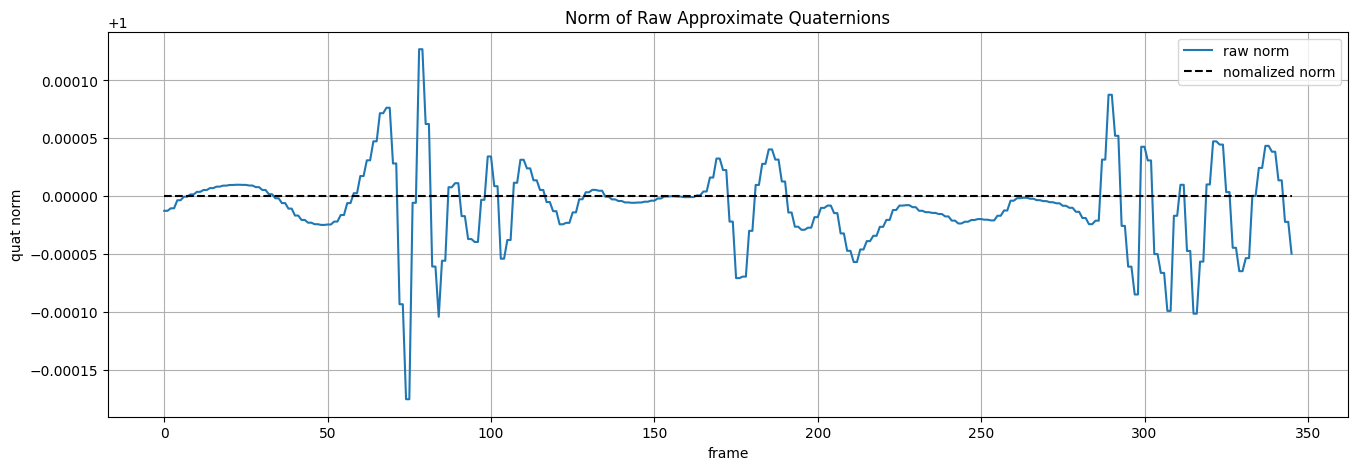

In [105]:
raw_quats_norms = np.linalg.norm(joint_raw_approx_quats, axis=1)
normed_quats_norms = np.linalg.norm(joint_normed_approx_quats, axis=1)

fig, ax = plt.subplots(1, 1, figsize=(16,5))

ax.plot(np.arange(NUM_FRAMES), raw_quats_norms, label="raw norm")
ax.plot(np.arange(NUM_FRAMES), normed_quats_norms, label="nomalized norm", linestyle="--", color="k")

ax.set_title("Norm of Raw Approximate Quaternions")
ax.set_xlabel("frame")
ax.set_ylabel("quat norm")
ax.grid()
ax.legend()
plt.show()

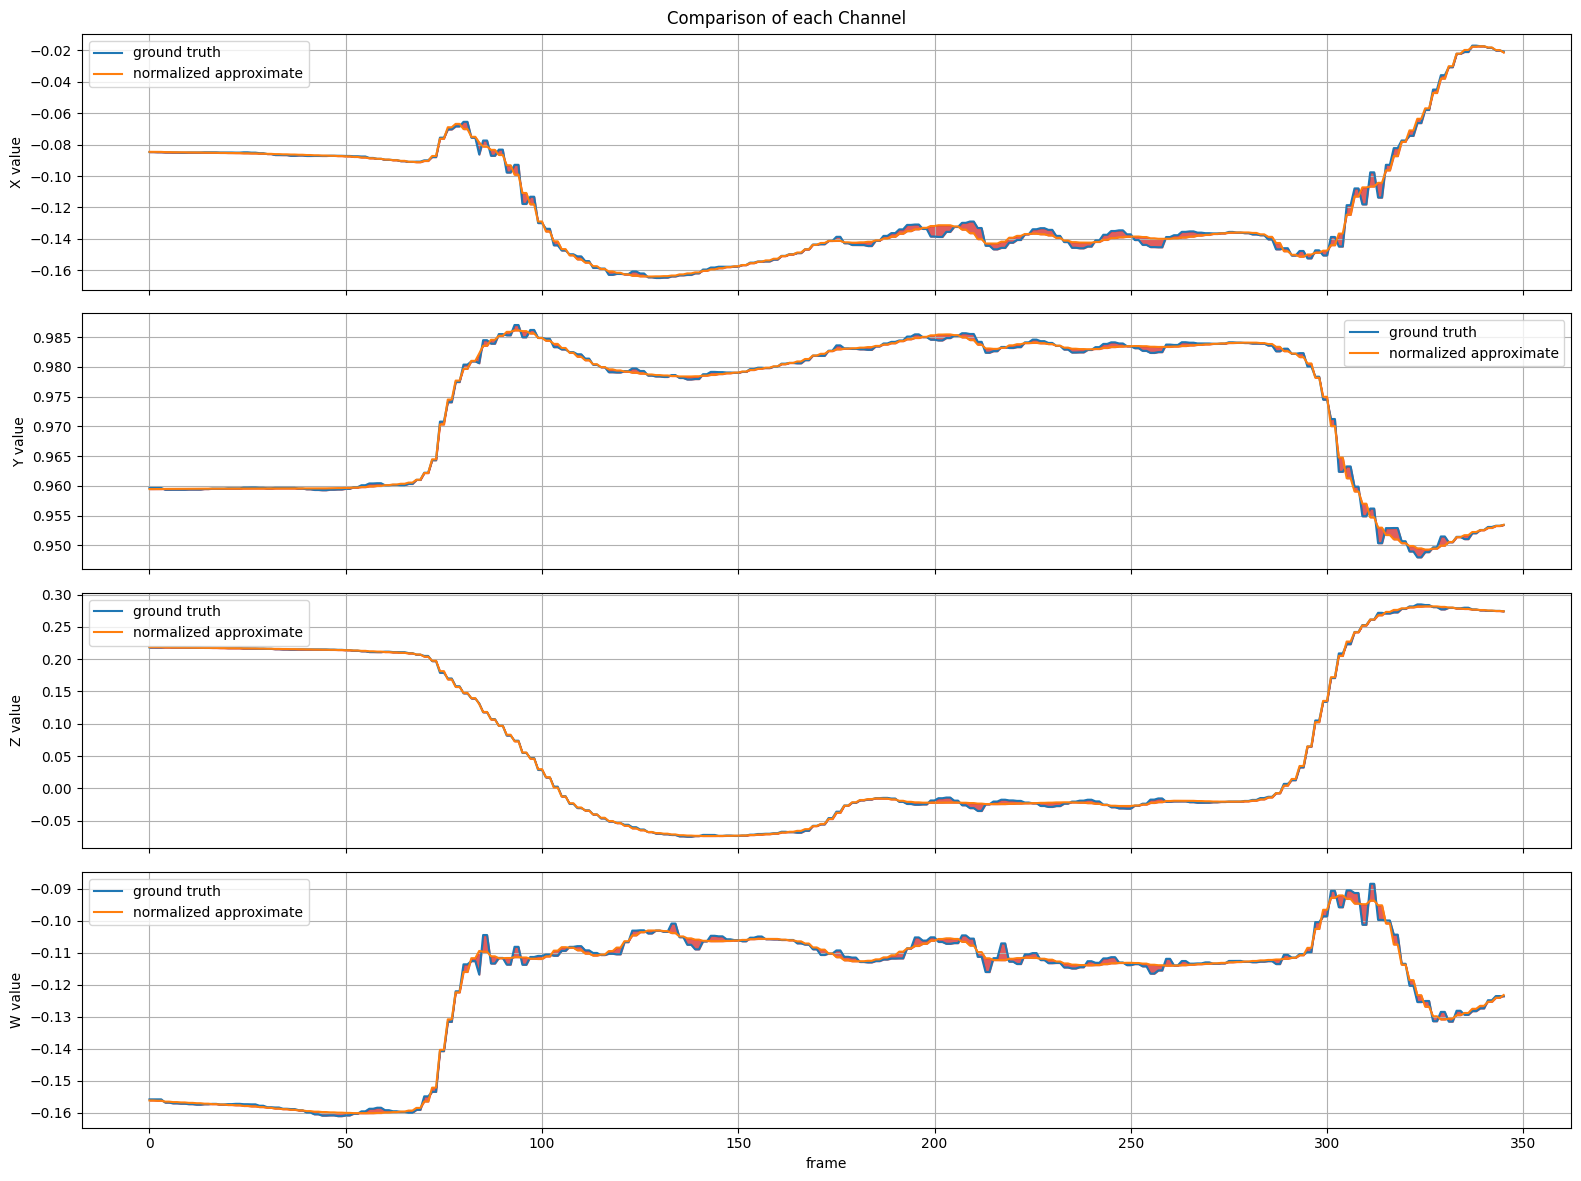

In [126]:
fig, axs = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
label = ["X", "Y", "Z", "W"]

for i in range(4):
    axs[i].plot(
        np.arange(NUM_FRAMES), joint_gt_quats[:,i],
        color="C0", label="ground truth",
        )
    axs[i].plot(
        np.arange(NUM_FRAMES), joint_normed_approx_quats[:,i],
        color="C1", label="normalized approximate",
        )
    axs[i].fill_between(
        np.arange(NUM_FRAMES), joint_gt_quats[:,i], joint_normed_approx_quats[:,i],
        color="C3", alpha=0.75,
        )

    axs[i].set_ylabel(f"{label[i]} value")
    axs[i].grid()
    axs[i].legend()

axs[-1].set_xlabel("frame")
fig.suptitle("Comparison of each Channel")
fig.tight_layout()
plt.show()